## Unsupervised Learning on Country Data


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [81]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\archive (2)\Country-data.csv")

In [82]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, explorative = True)
profile.to_file("HELP NGO DATA.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 27.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [83]:
df.corr(numeric_only = True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


In [84]:
X =df.drop(['country', "income"],axis = 1)

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size = 0.25, random_state = 42)

In [61]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_train_scaled)


In [62]:
from sklearn.cluster import KMeans

In [63]:
wcss = []
for i in range (1,11):
    kmean = KMeans(n_clusters = i,random_state = 42)
    kmean.fit(X_pca)
    wcss.append(kmean.inertia_)

c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

In [64]:
wcss

[633.0820588768429,
 328.8571067971261,
 245.83928229934162,
 198.67541143375857,
 174.27435020905816,
 149.23865311684114,
 102.27117215786132,
 94.63173824494761,
 78.500342761283,
 69.56659299731122]

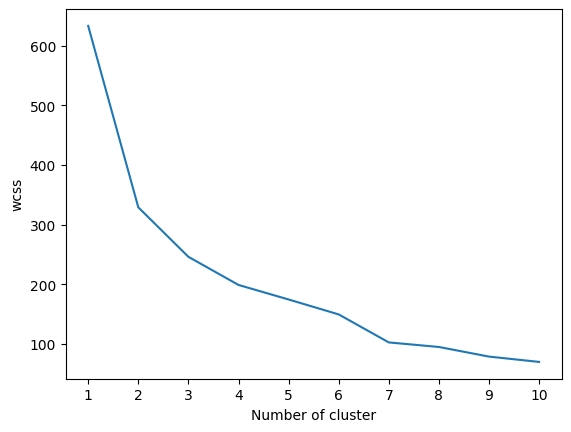

In [65]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of cluster")
plt.ylabel('wcss')
plt.show()

c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

k=2: Silhouette=0.4303
k=3: Silhouette=0.3793
k=4: Silhouette=0.3240
k=5: Silhouette=0.2943
k=6: Silhouette=0.3009


c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=7: Silhouette=0.3490
k=8: Silhouette=0.3104
k=9: Silhouette=0.3294


c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=10: Silhouette=0.3334


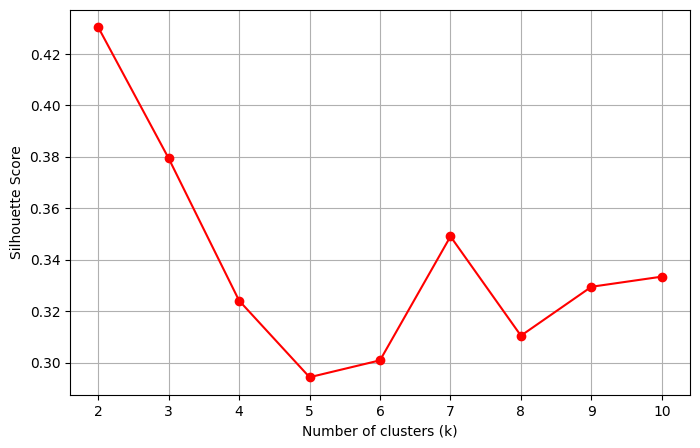

In [66]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11): 
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    silhouette_scores.append(sil)
    print(f"k={i}: Silhouette={sil:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, 'ro-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [67]:
kmean = KMeans(n_clusters = 2, init = 'k-means++')
y_labels = kmean.fit_predict(X_pca)

c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


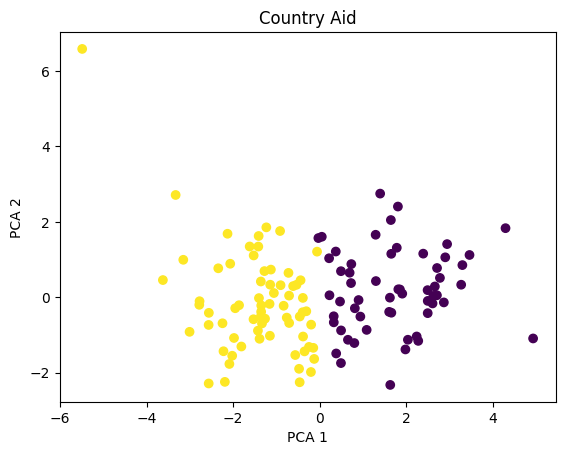

In [68]:
plt.scatter(X_pca[: , 0],X_pca[: , 1], c= y_labels)
plt.title("Country Aid")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**Fixing Centroid to Data_point**

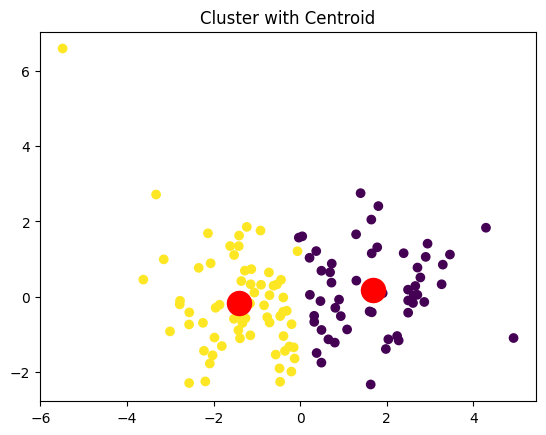

In [69]:
plt.scatter(X_pca[:, 0], X_pca[:,1],c=y_labels)
plt.scatter(kmean.cluster_centers_[:,0], kmean.cluster_centers_[:,1], s = 300, c ="red", marker = "o")
plt.title("Cluster with Centroid")
plt.show()

**Clustering on original features**

In [70]:
X_train['cluster']= y_labels

In [71]:
cluster_summary = X_train.groupby('cluster').mean()
print(cluster_summary)

         child_mort    exports    health    imports  inflation  life_expec  \
cluster                                                                      
0         74.663158  31.121035  5.704211  43.316946  12.793596   62.291228   
1         10.869118  46.260294  7.729706  45.936765   5.111088   76.698529   

         total_fer          gdpp  
cluster                           
0         4.358070   2344.754386  
1         1.895294  22244.264706  


In [72]:
df_train = df.loc[X_train.index].copy()
df_train['cluster'] = y_labels

In [73]:
aid_countries = df_train[df_train['cluster']==1]
aid_countries[['country', 'gdpp', 'child_mort', 'life_expec']]

,country,gdpp,child_mort,life_expec
143,Suriname,8300,24.1,70.3
85,Latvia,11300,7.8,73.1
96,Maldives,7100,13.2,77.9
118,Paraguay,3230,24.1,74.1
22,Brazil,11200,19.8,74.2
...,...,...,...,...
20,Bosnia and Herzegovina,4610,6.9,76.8
71,Iran,6530,19.3,74.5
14,Belarus,6030,5.5,70.4
92,"Macedonia, FYR",4540,10.4,74.0


In [74]:
top15 = aid_countries.sort_values(by='child_mort', ascending=False).head(15)
print(top15[['country', 'gdpp', 'child_mort', 'life_expec']])

         country   gdpp  child_mort  life_expec
46       Ecuador   4660        25.1        76.7
143     Suriname   8300        24.1        70.3
118     Paraguay   3230        24.1        74.1
52          Fiji   3650        24.1        65.3
164      Vietnam   1310        23.3        73.1
119         Peru   5020        20.3        77.9
22        Brazil  11200        19.8        74.2
117       Panama   8080        19.7        77.8
71          Iran   6530        19.3        74.5
48   El Salvador   2990        19.2        74.1
153       Turkey  10700        19.1        78.2
35      Colombia   6250        18.6        76.4
6        Armenia   3220        18.1        73.3
152      Tunisia   4140        17.4        76.9
102      Moldova   1630        17.2        69.7


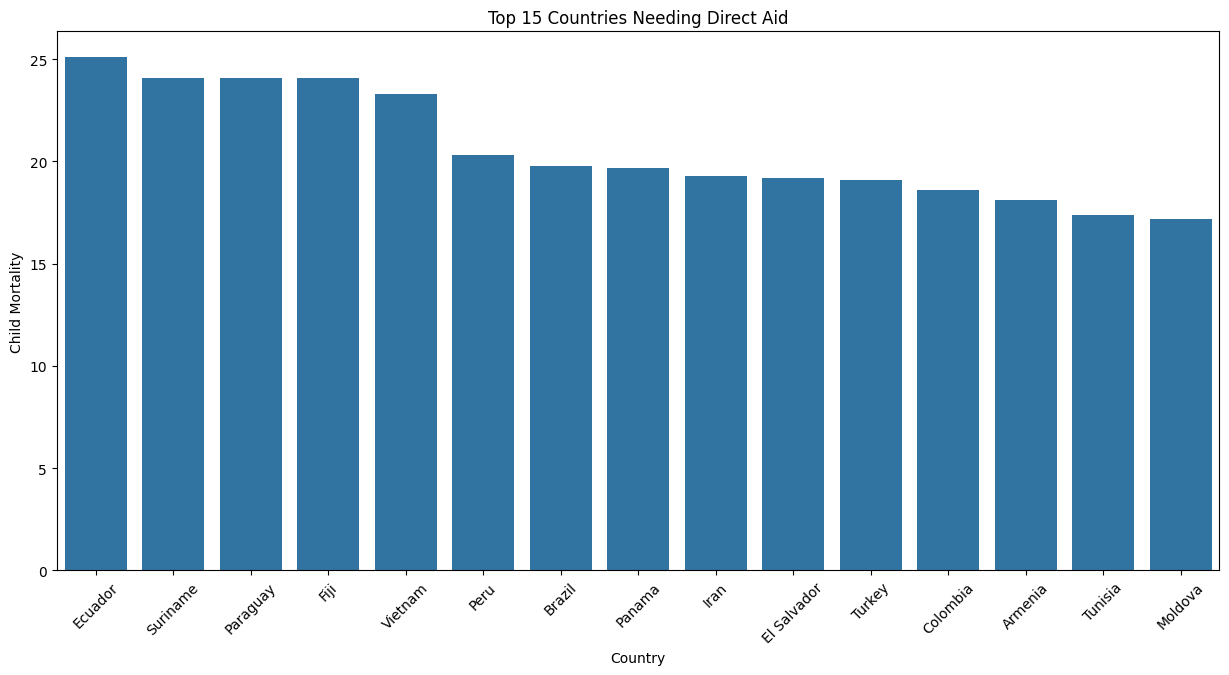

In [75]:
plt.figure(figsize=(15,7))

top15 = aid_countries.sort_values(by='child_mort', ascending=False).head(15)

sns.barplot(
    data=top15,
    x='country',
    y='child_mort'
)

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Child Mortality")
plt.title("Top 15 Countries Needing Direct Aid")
plt.show()

In [76]:
X_train['cluster'].value_counts()

cluster
1    68
0    57
Name: count, dtype: int64

In [77]:
silhouette_score(X_pca, y_labels)

0.43030086811059887

**Apply PCA and KMEAN on TEST data**

In [78]:
X_test_pca = pca.transform(X_test_scaled)
test_label = kmean.predict(X_test_pca)

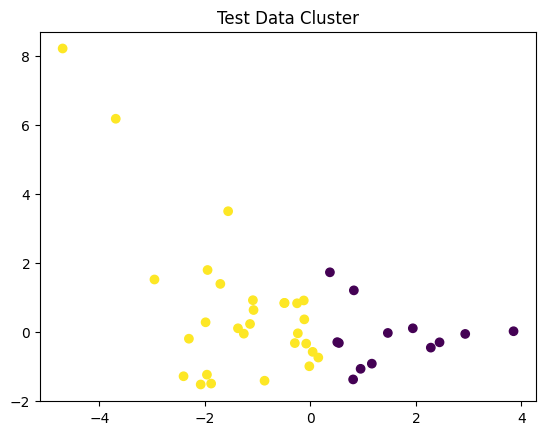

In [79]:
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c = test_label)
plt.title("Test Data Cluster")
plt.show()